# 📧 Spam Detection
### Naive Bayes — SMS Spam Collection Dataset

Importing libaries

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Importing Dataset

In [43]:
dataset = pd.read_csv("spam.csv", encoding="latin-1", usecols=[0, 1], names=["label", "message"], header=0)
dataset.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


Data Exploration

In [44]:
print(dataset.shape)
print(dataset["label"].value_counts())

(5572, 2)
label
ham     4825
spam     747
Name: count, dtype: int64


Target Transformation

In [45]:
dataset["label"] = dataset["label"].map({"ham": 0, "spam": 1})
print(dataset["label"].value_counts())

label
0    4825
1     747
Name: count, dtype: int64


Feature Extraction (Bag of Words)

In [46]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer()
x = vectorizer.fit_transform(dataset["message"])
y = dataset["label"]

print("Shape of x:", x.shape)

Shape of x: (5572, 8672)


Spliting Dataset into Training set and Test set

In [47]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

Training Naive Bayes Model

In [48]:
from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB()
model.fit(x_train, y_train)

print("Model trained succesfully!.")

Model trained succesfully!.


Model Evaluation

In [49]:
from sklearn.metrics import accuracy_score, precision_score, recall_score
y_pred = model.predict(x_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(f"Precision: {precision_score(y_test, y_pred):.2f}")
print(f"Recall: {recall_score(y_test, y_pred):.2f}")

Accuracy: 0.98
Precision: 0.91
Recall: 0.93


Confusion Matrix

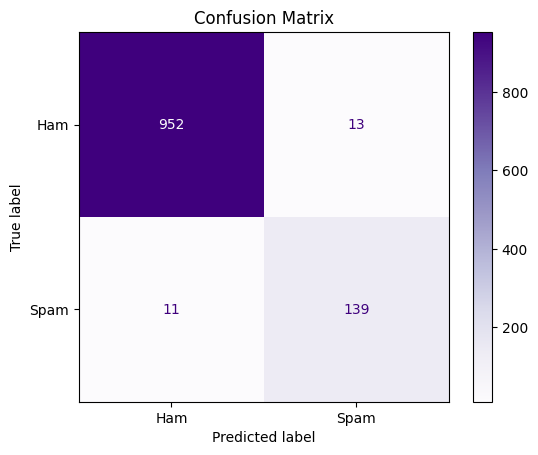

In [50]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Ham", "Spam"])
disp.plot(cmap="Purples")
plt.title("Confusion Matrix")
plt.show()

Top Spam Words

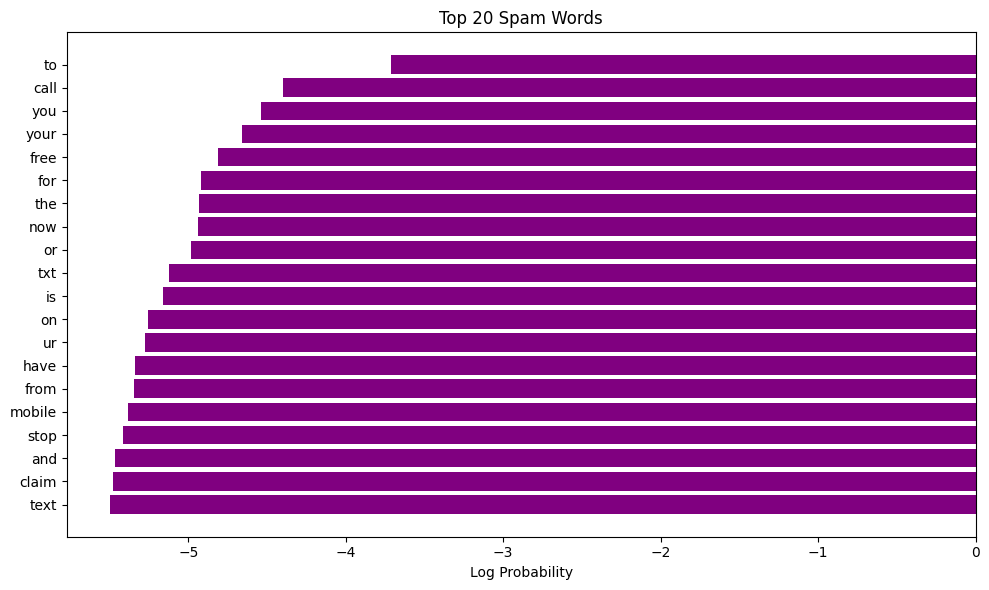

In [51]:
feature_names = vectorizer.get_feature_names_out()
spam_index = 1
log_probs = model.feature_log_prob_[spam_index]

top_indices = np.argsort(log_probs)[-20:]
top_words = [feature_names[i] for i in top_indices]
top_scores = [log_probs[i] for i in top_indices]

plt.figure(figsize=(10, 6))
plt.barh(top_words, top_scores, color="purple")
plt.xlabel("Log Probability")
plt.title("Top 20 Spam Words")
plt.tight_layout()
plt.show()